# NB4: Model Performance on Edge Years

Load the trained XGBoost model and scaler from NB3. Apply them to data from edge years 
(before and after the training period) to evaluate how well the model generalizes to 
out-of-distribution time periods.

In [ ]:
# ============================================================
# Colab setup — run this cell FIRST. Does nothing when run locally.
# ============================================================
import os, sys, shutil

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1) Clone repo (or pull if already cloned)
    if not os.path.exists("/content/ML_TND"):
        os.system("git clone -q https://github.com/lotteat11/ML_TND /content/ML_TND")
    else:
        os.system("cd /content/ML_TND && git pull -q")

    # 2) Install Python deps
    os.system("pip install -q xgboost scikit-learn pyarrow joblib")

    # 3) Download parquet from GitHub Releases (wget follows redirects reliably)
    dest = "/content/ML_TND/grace_workshop_small.parquet"
    if not os.path.exists(dest):
        print("Downloading grace_workshop_small.parquet (~257 MB)...")
        ret = os.system(
            f"wget -q --show-progress -O {dest} "
            "https://github.com/lotteat11/ML_TND/releases/download/v1.0-workshop/grace_workshop_small.parquet"
        )
        if ret != 0 or not os.path.exists(dest):
            raise RuntimeError("Download failed. Check your internet connection and re-run this cell.")
        print("Download complete.")

    # 4) chdir into workshop/ so all relative paths resolve
    os.chdir("/content/ML_TND/workshop")
    print("Setup complete — ready to run.")
else:
    print("Local run — no setup needed.")


In [40]:
%pip install -q xgboost scikit-learn pandas numpy matplotlib scipy joblib pyarrow


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Import Required Libraries

In [41]:
import sys, joblib
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import feature_functions as ff
from paths import GRACE_WORKSHOP as GRACE_MERGED

## 2. Load Data and Feature Engineering

Load the full GRACE dataset and apply the same feature engineering pipeline as NB3.

In [42]:
# Load the FULL dataset (not filtered like NB3)
df_full = pd.read_parquet(GRACE_MERGED)
df_full['time'] = pd.to_datetime(df_full['grace_time'])
df_full = df_full.sort_values('time').reset_index(drop=True)
df_full = df_full[(df_full['rho_obs'] > 0) & (df_full['msis_rho'] > 0)].reset_index(drop=True)
df_full['log_ratio'] = np.log(df_full['rho_obs'] / df_full['msis_rho'])

# Apply feature engineering
df_full = ff.add_lst_doy_features(df_full)
df_full['lon_sin']           = np.sin(np.deg2rad(df_full['lon']))
df_full['lon_cos']           = np.cos(np.deg2rad(df_full['lon']))
df_full['lst_lat_sin']       = df_full['lst_sin'] * df_full['lat']
df_full['vtec_matched_lag']  = df_full['matched_tec_value'].shift(500)
df_full['vtec_matched_lag2'] = df_full['matched_tec_value'].shift(17280)
df_full = df_full.dropna().reset_index(drop=True)

# Define features used in NB3
FEATURES = ['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat',
            'matched_tec_value', 'lst_sin', 'lst_cos', 'doy_sin', 'doy_cos',
            'lon_sin', 'lon_cos', 'vtec_matched_lag', 'vtec_matched_lag2', 'lst_lat_sin']
COLS_TO_SCALE = ['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat',
                 'matched_tec_value', 'vtec_matched_lag', 'vtec_matched_lag2']
TARGET = 'log_ratio'

print(f'Loaded {len(df_full):,} rows (full time range)')
print(f'Time range: {df_full["time"].min()} to {df_full["time"].max()}')

Loaded 7,070,334 rows (full time range)
Time range: 2009-01-02 00:00:00+00:00 to 2016-03-31 23:59:50+00:00


## 3. Load Trained Model and Scaler from NB3

In [43]:
# Load the trained cyclic-split model and scaler
scaler = joblib.load("nb3_scaler_cyclic.joblib")
model = xgb.XGBRegressor()
model.load_model("nb3_model_cyclic.json")

print("Loaded trained model and scaler from NB3")
print(f"Model type: {type(model)}")
print(f"Scaler type: {type(scaler)}")

Loaded trained model and scaler from NB3
Model type: <class 'xgboost.sklearn.XGBRegressor'>
Scaler type: <class 'sklearn.preprocessing._data.MinMaxScaler'>


## 4. Prepare Edge Years Data

NB3 used data from 2009-06-01 to 2016-01-01. Extract data from the edge years 
(before 2009-06-01 and after 2016-01-01) to test on out-of-distribution data.

In [44]:
# Define the NB3 training period
# Remove timezone info for comparison if it exists
df_full['time_naive'] = df_full['time'].dt.tz_localize(None) if df_full['time'].dt.tz is not None else df_full['time']

TRAIN_START = pd.Timestamp('2009-06-01')
TRAIN_END   = pd.Timestamp('2016-01-01')

# Extract edge years (before and after)
df_before = df_full[df_full['time_naive'] < TRAIN_START].copy()
df_after  = df_full[df_full['time_naive'] >= TRAIN_END].copy()

print(f"Data before training period: {len(df_before):,} rows ({df_before['time'].min()} to {df_before['time'].max()})")
print(f"Data after training period:  {len(df_after):,} rows ({df_after['time'].min()} to {df_after['time'].max()})")
print(f"Total edge years data: {len(df_before) + len(df_after):,} rows")

# Combine for analysis
df_edges = pd.concat([df_before, df_after], ignore_index=False).sort_values('time')
print(f"\nEdge years combined: {len(df_edges):,} rows")

Data before training period: 1,525,871 rows (2009-01-02 00:00:00+00:00 to 2009-03-31 23:59:50+00:00)
Data after training period:  1,560,014 rows (2016-01-01 00:00:00+00:00 to 2016-03-31 23:59:50+00:00)
Total edge years data: 3,085,885 rows

Edge years combined: 3,085,885 rows


## 5. Apply Model to Edge Years

Scale the features using the trained scaler and make predictions.

In [45]:
# Prepare features for edge years
X_edges = df_edges[FEATURES].copy()

# Scale using the trained scaler
X_edges_scaled = X_edges.copy()
X_edges_scaled[COLS_TO_SCALE] = scaler.transform(X_edges[COLS_TO_SCALE])

# Make predictions in log-space
y_edges_pred_log = model.predict(X_edges_scaled)

# Convert to physical density space: rho = msis_rho * exp(log_ratio)
rho_msis = df_edges['msis_rho'].values
rho_obs = df_edges['rho_obs'].values
rho_pred = rho_msis * np.exp(y_edges_pred_log)

# Store in dataframe for later use
df_edges['rho_pred'] = rho_pred
df_edges['y_pred_log'] = y_edges_pred_log

# Also add predictions back to df_before and df_after using index alignment
df_before['rho_pred'] = df_before.index.map(df_edges.set_index(df_edges.index)['rho_pred'])
df_after['rho_pred'] = df_after.index.map(df_edges.set_index(df_edges.index)['rho_pred'])

print(f"Made predictions for {len(df_edges):,} edge years samples")
print(f"Prediction range: {rho_pred.min():.3e} to {rho_pred.max():.3e} kg/m³")

Made predictions for 3,085,885 edge years samples
Prediction range: 2.563e-14 to 6.386e-12 kg/m³


## 6. Evaluate Model Performance on Edge Years

In [46]:
# Summary by period
print("\nPeriod-by-period breakdown:")
for period_name, df_period in [("Pre-2009", df_before), ("Post-2016", df_after)]:
    if len(df_period) > 0:
        rho_obs_p = df_period['rho_obs'].values
        rho_pred_p = df_period['rho_pred'].values
        rho_msis_p = df_period['msis_rho'].values
        mask_p = (rho_obs_p > 0) & (rho_pred_p > 0) & (rho_msis_p > 0)
        if mask_p.sum() > 0:
            rmse_p = np.sqrt(np.mean((rho_obs_p[mask_p] - rho_pred_p[mask_p]) ** 2))
            rmse_msis_p = np.sqrt(np.mean((rho_obs_p[mask_p] - rho_msis_p[mask_p]) ** 2))
            r2_p = r2_score(rho_obs_p[mask_p], rho_pred_p[mask_p])
            r2_msis_p = r2_score(rho_obs_p[mask_p], rho_msis_p[mask_p])
            improvement = (rmse_msis_p - rmse_p) / rmse_msis_p * 100
            print(f"\n  {period_name} ({mask_p.sum():,} samples):")
            print(f"    MSIS RMSE:  {rmse_msis_p:.3e} kg/m³")
            print(f"    Model RMSE: {rmse_p:.3e} kg/m³  (improvement: {improvement:+.1f}%)")
            print(f"    Model R²:   {r2_p:.4f}  vs MSIS R²: {r2_msis_p:.4f}")


Period-by-period breakdown:

  Pre-2009 (1,525,871 samples):
    MSIS RMSE:  7.030e-14 kg/m³
    Model RMSE: 5.090e-14 kg/m³  (improvement: +27.6%)
    Model R²:   0.1646  vs MSIS R²: -0.5939

  Post-2016 (1,560,014 samples):
    MSIS RMSE:  5.245e-13 kg/m³
    Model RMSE: 4.309e-13 kg/m³  (improvement: +17.8%)
    Model R²:   0.8584  vs MSIS R²: 0.7902


## 7. Visualize Predictions vs Observations

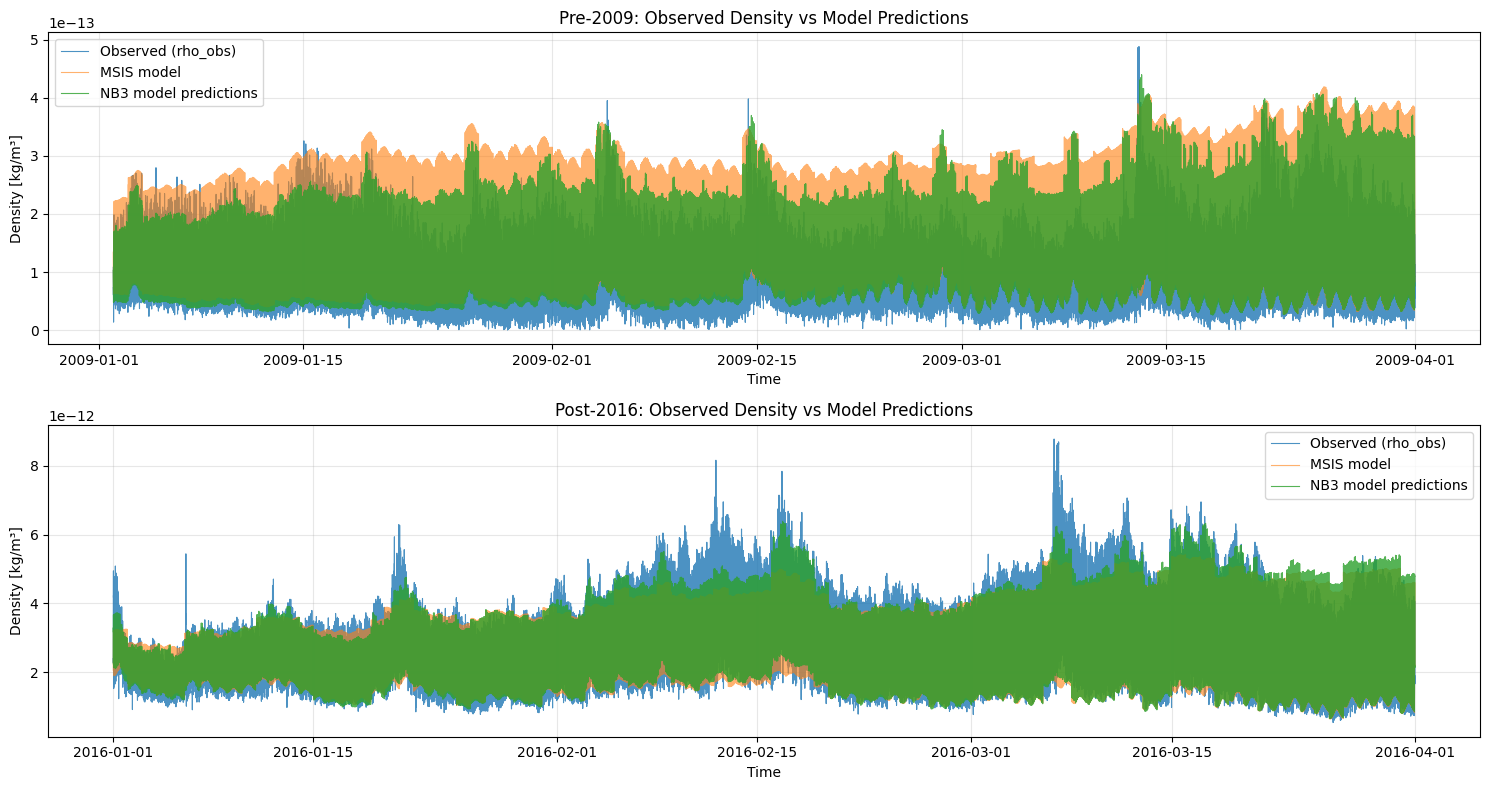

In [47]:
# Time series: observed, MSIS, and model predictions (separate for each period)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

# Pre-2009 plot
if len(df_before) > 0:
    time_before = df_before['time_naive'] if 'time_naive' in df_before.columns else df_before['time'].dt.tz_localize(None) if df_before['time'].dt.tz is not None else df_before['time']
    rho_obs_before = df_before['rho_obs'].values
    rho_msis_before = df_before['msis_rho'].values
    rho_pred_before = df_before['rho_pred'].values
    
    ax1.plot(time_before[::5], rho_obs_before[::5], lw=0.8, label='Observed (rho_obs)', color='C0', alpha=0.8)
    ax1.plot(time_before[::5], rho_msis_before[::5], lw=0.8, label='MSIS model', color='C1', alpha=0.6)
    ax1.plot(time_before[::5], rho_pred_before[::5], lw=0.8, label='NB3 model predictions', color='C2', alpha=0.8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Density [kg/m³]')
    ax1.set_title('Pre-2009: Observed Density vs Model Predictions')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

# Post-2016 plot
if len(df_after) > 0:
    time_after = df_after['time_naive'] if 'time_naive' in df_after.columns else df_after['time'].dt.tz_localize(None) if df_after['time'].dt.tz is not None else df_after['time']
    rho_obs_after = df_after['rho_obs'].values
    rho_msis_after = df_after['msis_rho'].values
    rho_pred_after = df_after['rho_pred'].values
    
    ax2.plot(time_after[::5], rho_obs_after[::5], lw=0.8, label='Observed (rho_obs)', color='C0', alpha=0.8)
    ax2.plot(time_after[::5], rho_msis_after[::5], lw=0.8, label='MSIS model', color='C1', alpha=0.6)
    ax2.plot(time_after[::5], rho_pred_after[::5], lw=0.8, label='NB3 model predictions', color='C2', alpha=0.8)
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Density [kg/m³]')
    ax2.set_title('Post-2016: Observed Density vs Model Predictions')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

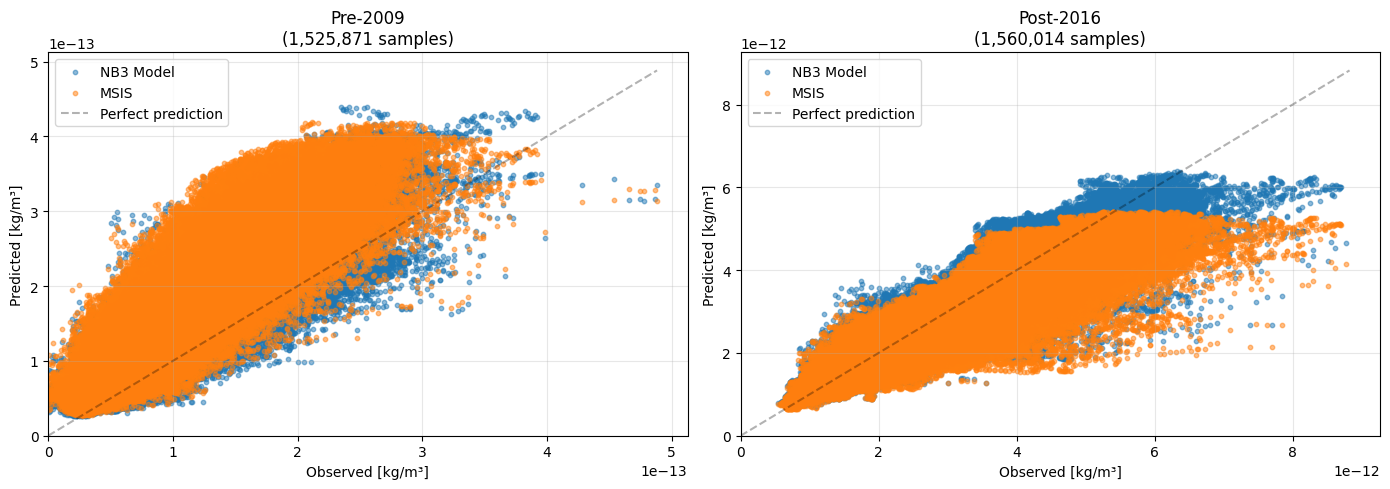

In [48]:
# Scatter: observed vs predicted and MSIS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before training period
if len(df_before) > 0:
    mask_b = (df_before['rho_obs'] > 0) & (df_before['rho_pred'] > 0)
    mask_b_msis = (df_before['rho_obs'] > 0) & (df_before['msis_rho'] > 0)
    ax1.scatter(df_before.loc[mask_b, 'rho_obs'][::5], df_before.loc[mask_b, 'rho_pred'][::5], 
                alpha=0.5, s=10, color='C0', label='NB3 Model')
    ax1.scatter(df_before.loc[mask_b_msis, 'rho_obs'][::5], df_before.loc[mask_b_msis, 'msis_rho'][::5], 
                alpha=0.5, s=10, color='C1', label='MSIS')
    ax1.plot([0, df_before['rho_obs'].max()], [0, df_before['rho_obs'].max()], 'k--', alpha=0.3, label='Perfect prediction')
    ax1.set_xlim(left=0)
    ax1.set_ylim(bottom=0)
    ax1.set_xlabel('Observed [kg/m³]')
    ax1.set_ylabel('Predicted [kg/m³]')
    ax1.set_title(f'Pre-2009\n({len(df_before):,} samples)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# After training period
if len(df_after) > 0:
    mask_a = (df_after['rho_obs'] > 0) & (df_after['rho_pred'] > 0)
    mask_a_msis = (df_after['rho_obs'] > 0) & (df_after['msis_rho'] > 0)
    ax2.scatter(df_after.loc[mask_a, 'rho_obs'][::5], df_after.loc[mask_a, 'rho_pred'][::5], 
                alpha=0.5, s=10, color='C0', label='NB3 Model')
    ax2.scatter(df_after.loc[mask_a_msis, 'rho_obs'][::5], df_after.loc[mask_a_msis, 'msis_rho'][::5], 
                alpha=0.5, s=10, color='C1', label='MSIS')
    ax2.plot([0, df_after['rho_obs'].max()], [0, df_after['rho_obs'].max()], 'k--', alpha=0.3, label='Perfect prediction')
    ax2.set_xlim(left=0)
    ax2.set_ylim(bottom=0)
    ax2.set_xlabel('Observed [kg/m³]')
    ax2.set_ylabel('Predicted [kg/m³]')
    ax2.set_title(f'Post-2016\n({len(df_after):,} samples)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The NB3 model trained on the 2009-06-01 to 2016-01-01 period has been applied to edge years data 
(before and after the training period). This tests how well the model generalizes to out-of-distribution 
time periods with potentially different atmospheric conditions.

**Key Observations:**
- Model performance on edge years gives insight into temporal generalization
- Residual plots help identify systematic biases or failure modes
- Comparison with MSIS baseline shows the value of the learned model

## 8. Warm-Start Rolling Forecast (5-day lookback → 3-day forecast)

This is the proper warm-start forecasting scheme from the paper (`Forecast/on_track.py`).

For each forecast day, we **fine-tune the base model on the previous 5 days** (the lookback
window), then **forecast the next 3 days** (the horizon). We advance one day at a time, so every
forecast is made on data the model has *not* seen during that step's fine-tuning.

Because the fine-tune window always sits **immediately before** the forecast window, recent
space-weather conditions carry into the forecast — this is why warm-start beats plain MSIS.

We evaluate on the post-2016 edge period (out-of-distribution for the NB3 model) and report the
same metrics as the paper: RMSE, Top-5% error, MAPE and R² in both linear and log density space.

In [ ]:
# Warm-start rolling forecast: fine-tune on previous LOOKBACK days, forecast next HORIZON days
import copy

# ---------------- CONFIG ----------------
LOOKBACK_DAYS    = 5      # days of recent data to fine-tune on
FORECAST_HORIZON = 3      # days ahead to forecast each step
RESET_EVERY      = 3      # reset to the original model every N steps (lower = less drift)
FINETUNE_ROUNDS  = 100    # max extra trees added per warm-start step (lower = less overfit/drift)
EDGE_PERIOD      = "post2016"   # "post2016" or "pre2009"
EVAL_WEEKS       = None   # limit to first N weeks of edge period (None = all); set e.g. 1 for a quick test
# ----------------------------------------

# Choose the edge dataframe (already feature-engineered as df_before / df_after in section 4)
df_edge = df_after.copy() if EDGE_PERIOD == "post2016" else df_before.copy()
df_edge["time"] = pd.to_datetime(df_edge["time"])
df_edge["date"] = df_edge["time"].dt.date
df_edge = df_edge.sort_values("time").reset_index(drop=True)

unique_dates = sorted(df_edge["date"].unique())

# Optionally restrict to the first EVAL_WEEKS weeks (keep LOOKBACK_DAYS of history before the first forecast)
if EVAL_WEEKS is not None:
    n_keep = LOOKBACK_DAYS + EVAL_WEEKS * 7
    unique_dates = unique_dates[:n_keep]
    df_edge = df_edge[df_edge["date"].isin(unique_dates)].reset_index(drop=True)
    print(f"(EVAL_WEEKS={EVAL_WEEKS}: limited to first {len(unique_dates)} days)")

print(f"Edge period '{EDGE_PERIOD}': {len(df_edge):,} rows over {len(unique_dates)} days")
print(f"  {unique_dates[0]} → {unique_dates[-1]}")
print(f"Rolling forecast: {LOOKBACK_DAYS}-day lookback → {FORECAST_HORIZON}-day horizon\n")


def lr_scheduler_ws(current_round):
    """Low LR for the first few rounds, then exponential decay (matches on_track.py)."""
    initial_lr = 0.03
    if current_round < 4:
        initial_lr = 1e-7
    return initial_lr * (0.9 ** (current_round // 12))


def finetune_on_window(base_booster, train_df):
    """Warm-start the booster on train_df using a random block train/val split + early stopping.
    NB3 does NOT scale the target, so we train directly on log_ratio."""
    train_df = train_df.sort_values("time").reset_index(drop=True)

    # Random 4/2 block split into train / val (K=6 blocks)
    K = 6
    block_size = max(1, len(train_df) // K)
    np.random.seed(42)
    train_blocks = np.random.choice(np.arange(K), size=int(K * 2 / 3), replace=False)

    train_chunks, val_chunks = [], []
    for j in range(K):
        s = j * block_size
        e = len(train_df) if j == K - 1 else s + block_size
        (train_chunks if j in train_blocks else val_chunks).append(train_df.iloc[s:e])

    df_tr = pd.concat(train_chunks).sort_values("time")
    df_va = pd.concat(val_chunks).sort_values("time")

    def prep(chunk):
        Xs = chunk[FEATURES].copy()
        Xs[COLS_TO_SCALE] = scaler.transform(chunk[COLS_TO_SCALE])
        return Xs[FEATURES]

    dtrain = xgb.DMatrix(prep(df_tr), label=df_tr["log_ratio"].values)
    dval   = xgb.DMatrix(prep(df_va), label=df_va["log_ratio"].values)

    updated = xgb.train(
        {"objective": "reg:squarederror", "eval_metric": "rmse"},
        dtrain,
        num_boost_round=FINETUNE_ROUNDS,
        evals=[(dtrain, "train"), (dval, "val")],
        xgb_model=base_booster,
        callbacks=[
            xgb.callback.EarlyStopping(rounds=30, save_best=True),
            xgb.callback.LearningRateScheduler(lr_scheduler_ws),
        ],
        verbose_eval=False,
    )
    return updated


# Base booster from the NB3 model (kept pristine so we can reset to it)
original_booster = model.get_booster()
base_booster = original_booster

all_preds = []
step_dates, step_rmse_ws, step_rmse_frozen = [], [], []
step = 0

def _density_rmse(window_df, booster):
    """RMSE in physical density space for one forecast window."""
    Xw = window_df[FEATURES].copy()
    Xw[COLS_TO_SCALE] = scaler.transform(window_df[COLS_TO_SCALE])
    pl = booster.predict(xgb.DMatrix(Xw[FEATURES]))
    rho = window_df["msis_rho"].values * np.exp(pl)
    return pl, rho, float(np.sqrt(np.mean((window_df["rho_obs"].values - rho) ** 2)))

# Start once we have LOOKBACK_DAYS of history, stop so the horizon window fits
for start_idx in range(LOOKBACK_DAYS, len(unique_dates) - FORECAST_HORIZON + 1):
    step += 1

    # Periodic reset to the original model (deepcopy so the pristine base is never mutated)
    if step % RESET_EVERY == 0:
        base_booster = copy.deepcopy(original_booster)

    # ---- Fine-tune on previous LOOKBACK_DAYS ----
    prev_days  = unique_dates[start_idx - LOOKBACK_DAYS:start_idx]
    train_data = df_edge[df_edge["date"].isin(prev_days)]
    if len(train_data) > 50:
        base_booster = finetune_on_window(base_booster, train_data)

    # ---- Forecast next FORECAST_HORIZON days ----
    window_days = unique_dates[start_idx:start_idx + FORECAST_HORIZON]
    window_data = df_edge[df_edge["date"].isin(window_days)].copy()
    if len(window_data) == 0:
        continue

    # Warm-start prediction (fine-tuned model) and frozen-baseline prediction (original NB3 model)
    pred_log, rho_ws,     rmse_ws     = _density_rmse(window_data, base_booster)
    _,        rho_frozen, rmse_frozen = _density_rmse(window_data, original_booster)

    step_dates.append(window_data["time"].iloc[0])
    step_rmse_ws.append(rmse_ws)
    step_rmse_frozen.append(rmse_frozen)

    window_data["y_pred_log"] = pred_log
    window_data["rho_pred"]        = rho_ws
    window_data["rho_pred_frozen"] = rho_frozen
    all_preds.append(window_data[["time", "date", "rho_obs", "msis_rho", "rho_pred", "rho_pred_frozen", "log_ratio", "y_pred_log"]])

pred_ws = pd.concat(all_preds).reset_index(drop=True)
rmse_ws_mean     = float(np.mean(step_rmse_ws))
rmse_frozen_mean = float(np.mean(step_rmse_frozen))

print(f"✅ Rolling warm-start complete: {len(pred_ws):,} forecast rows over {step} steps")
print(f"   Prediction range: {pred_ws['rho_pred'].min():.3e} → {pred_ws['rho_pred'].max():.3e} kg/m³")
print(f"   Mean RMSE  warm-start: {rmse_ws_mean:.3e}  |  frozen base: {rmse_frozen_mean:.3e} kg/m³")

In [ ]:
# Validation — paper metrics (RMSE, Top-5%, MAPE, R²) in linear and log space
print("=" * 78)
print(f"WARM-START ROLLING FORECAST — VALIDATION ({EDGE_PERIOD}, "
      f"{LOOKBACK_DAYS}d lookback → {FORECAST_HORIZON}d horizon)")
print("=" * 78)

d = pred_ws.dropna(subset=["rho_obs", "msis_rho", "rho_pred"]).copy()
m = (d["rho_obs"] > 0) & (d["msis_rho"] > 0) & (d["rho_pred"] > 0)
obs  = d.loc[m, "rho_obs"].to_numpy()
msis = d.loc[m, "msis_rho"].to_numpy()
pred = d.loc[m, "rho_pred"].to_numpy()

def paper_metrics(y, yhat):
    """RMSE/Top5/MAPE/R² in linear space + RMSE_log/Top5_log in log space."""
    ly, lyhat = np.log(y), np.log(yhat)
    n = y.size
    k = max(1, int(np.ceil(0.05 * n)))                      # top 5% worst errors
    ae_lin = np.abs(y - yhat)
    ae_log = np.abs(ly - lyhat)
    return {
        "RMSE_log":   np.sqrt(np.mean((ly - lyhat) ** 2)),
        "Top5_log":   np.mean(np.sort(ae_log)[-k:]),
        "RMSE":       np.sqrt(np.mean((y - yhat) ** 2)),
        "Top5":       np.mean(np.sort(ae_lin)[-k:]),
        "MAPE_pct":   np.mean(np.abs((y - yhat) / y)) * 100.0,
        "R2":         r2_score(y, yhat),
    }

mm = paper_metrics(obs, msis)
pm = paper_metrics(obs, pred)

print(f"\nEvaluated on {obs.size:,} forecast samples\n")
rows = [
    ("RMSE_log",            f"{mm['RMSE_log']:.3f}", f"{pm['RMSE_log']:.3f}"),
    ("Top5_log",            f"{mm['Top5_log']:.3f}", f"{pm['Top5_log']:.3f}"),
    ("RMSE (kg m⁻³)", f"{mm['RMSE']:.3e}",   f"{pm['RMSE']:.3e}"),
    ("Top5 (kg m⁻³)", f"{mm['Top5']:.3e}",   f"{pm['Top5']:.3e}"),
    ("MAPE (%)",            f"{mm['MAPE_pct']:.1f}", f"{pm['MAPE_pct']:.1f}"),
    ("R2",                  f"{mm['R2']:.3f}",       f"{pm['R2']:.3f}"),
]
table = pd.DataFrame(rows, columns=["Metric", "NRLMSISE-2.1", "Pred (Warm-start)"])

# Diff column: signed % change of Pred vs MSIS (negative = error reduced)
def pct(a, b):
    return f"{(b - a) / abs(a) * 100:+.1f}%" if a != 0 else "n/a"
table["Diff (%)"] = [
    pct(mm["RMSE_log"], pm["RMSE_log"]),
    pct(mm["Top5_log"], pm["Top5_log"]),
    pct(mm["RMSE"],     pm["RMSE"]),
    pct(mm["Top5"],     pm["Top5"]),
    pct(mm["MAPE_pct"], pm["MAPE_pct"]),
    pct(mm["R2"],       pm["R2"]),
]
print(table.to_string(index=False))

rmse_impr = (mm["RMSE"] - pm["RMSE"]) / mm["RMSE"] * 100
print("\n" + "-" * 78)
if rmse_impr > 1:
    print(f"✅ Warm-start beats MSIS by {rmse_impr:.1f}% RMSE "
          f"(R² {mm['R2']:.3f} → {pm['R2']:.3f})")
elif rmse_impr < -1:
    print(f"⚠️  Warm-start is {abs(rmse_impr):.1f}% worse than MSIS in RMSE")
else:
    print(f"~ Warm-start ≈ MSIS ({rmse_impr:+.1f}% RMSE)")
print("=" * 78)


In [ ]:
# Validation plot — density time series + parity (R² only, no Pearson r)
# Show first 3 days of the warm-start forecast
d_all = pred_ws.dropna(subset=["rho_obs", "msis_rho", "rho_pred"]).copy()
t_end = d_all["time"].iloc[0] + pd.Timedelta(days=3)
d = d_all[d_all["time"] < t_end].iloc[::5]
mp = (d["rho_obs"] > 0) & (d["msis_rho"] > 0) & (d["rho_pred"] > 0)
t    = d.loc[mp, "time"]
obs  = d.loc[mp, "rho_obs"].to_numpy()
msis = d.loc[mp, "msis_rho"].to_numpy()
pred = d.loc[mp, "rho_pred"].to_numpy()

# Reuse the metrics already computed above (mm = MSIS, pm = Pred)
msis_label = (f"MSIS\nRMSE(log)={mm['RMSE_log']:.3f}\nRMSE={mm['RMSE']:.2e}\n"
              f"MAPE={mm['MAPE_pct']:.1f}%, R²={mm['R2']:.3f}")
pred_label = (f"Warm-start\nRMSE(log)={pm['RMSE_log']:.3f}\nRMSE={pm['RMSE']:.2e}\n"
              f"MAPE={pm['MAPE_pct']:.1f}%, R²={pm['R2']:.3f}")

# Time series
fig1 = plt.figure(figsize=(12, 5))
plt.plot(t, obs,  label="Observed",   color="k",  lw=1.0, alpha=0.8)
plt.plot(t, msis, label="MSIS",       color="C1", lw=1.0, alpha=0.8)
plt.plot(t, pred, label="Warm-start", color="C0", lw=1.0, alpha=0.8)
plt.yscale("log")
plt.xlabel("Time"); plt.ylabel("Density [kg m$^{-3}$] (log scale)")
plt.title(f"Validation: Observed vs MSIS vs Warm-start ({EDGE_PERIOD})")
plt.legend(); plt.tight_layout(); plt.show()

# Parity
vmax = float(np.nanmax([obs.max(), msis.max(), pred.max()]))
vmin = max(1e-15, float(np.nanmin([obs.min(), msis.min(), pred.min()])))
fig2 = plt.figure(figsize=(6.5, 6.5))
plt.scatter(obs, msis, s=8, alpha=0.5, color="C1", label=msis_label)
plt.scatter(obs, pred, s=8, alpha=0.5, color="C0", label=pred_label)
plt.plot([vmin, vmax], [vmin, vmax], "k--", lw=1)
plt.xlabel("Observed density [kg m$^{-3}$]")
plt.ylabel("Modeled density [kg m$^{-3}$]")
plt.title("Parity (Validation)")
plt.legend(loc="lower right", framealpha=0.9, fontsize="small")
plt.tight_layout(); plt.show()


## 9. Warm-Start vs Frozen Baseline (rolling comparison)

At each step the loop forecasts the window twice: once with the **warm-started** model (fine-tuned
on the previous 5 days) and once with the **frozen** NB3 base model (never updated). Comparing their
per-step RMSE shows whether fine-tuning on recent data actually helps the forecast.

In [ ]:
# Rolling RMSE over the forecast run: warm-start vs frozen base model
window = max(1, len(step_dates) // 20)
ws_smooth     = pd.Series(step_rmse_ws).rolling(window, min_periods=1).mean()
frozen_smooth = pd.Series(step_rmse_frozen).rolling(window, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(step_dates, ws_smooth,     label=f'Warm-start  (mean={rmse_ws_mean:.2e})',     color='C0', lw=1.4)
ax.plot(step_dates, frozen_smooth, label=f'Frozen base (mean={rmse_frozen_mean:.2e})', color='C3', lw=1.4, linestyle='--')
ax.set_ylabel('RMSE  [kg m$^{-3}$] (rolling avg)')
ax.set_xlabel('Forecast date')
ax.set_title(f'Gap evolution — {EDGE_PERIOD}, LOOKBACK={LOOKBACK_DAYS}d, HORIZON={FORECAST_HORIZON}d')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Frozen base model vs warm-start — paper metrics on the same forecast samples
obs2    = pred_ws["rho_obs"].to_numpy()
frozen2 = pred_ws["rho_pred_frozen"].to_numpy()
ws2     = pred_ws["rho_pred"].to_numpy()
mok     = (obs2 > 0) & (frozen2 > 0) & (ws2 > 0)

fm = paper_metrics(obs2[mok], frozen2[mok])   # frozen base model
wm = paper_metrics(obs2[mok], ws2[mok])       # warm-start

print("=" * 78)
print(f"FROZEN BASE vs WARM-START  ({EDGE_PERIOD}, {LOOKBACK_DAYS}d lookback -> {FORECAST_HORIZON}d horizon)")
print("=" * 78)
print(f"\nEvaluated on {mok.sum():,} forecast samples\n")

rows = [
    ("RMSE_log",      f"{fm['RMSE_log']:.3f}", f"{wm['RMSE_log']:.3f}"),
    ("Top5_log",      f"{fm['Top5_log']:.3f}", f"{wm['Top5_log']:.3f}"),
    ("RMSE (kg m-3)", f"{fm['RMSE']:.3e}",     f"{wm['RMSE']:.3e}"),
    ("Top5 (kg m-3)", f"{fm['Top5']:.3e}",     f"{wm['Top5']:.3e}"),
    ("MAPE (%)",      f"{fm['MAPE_pct']:.1f}", f"{wm['MAPE_pct']:.1f}"),
    ("R2",            f"{fm['R2']:.3f}",       f"{wm['R2']:.3f}"),
]
cmp_table = pd.DataFrame(rows, columns=["Metric", "Frozen base", "Warm-start"])
cmp_table["Diff (%)"] = [
    pct(fm["RMSE_log"], wm["RMSE_log"]),
    pct(fm["Top5_log"], wm["Top5_log"]),
    pct(fm["RMSE"],     wm["RMSE"]),
    pct(fm["Top5"],     wm["Top5"]),
    pct(fm["MAPE_pct"], wm["MAPE_pct"]),
    pct(fm["R2"],       wm["R2"]),
]
print(cmp_table.to_string(index=False))
print("=" * 78)
